
CACHE FOUND: Loading dataset directly from 'master_multimodal_lstm_dataset.csv'...

Fixing missing (null) data by filling with 0...

PHASE 3: Training Hybrid ARX-LSTM with Class Weighting...
--------------------------------------------------
Data Imbalance Detected: 29675 OFF states vs 96 ON states.
Applying BCE Positive Weight: 309.11
Epoch [1/20] | Joint Train Loss: 0.34711 | Val Acc: 99.13%
Epoch [5/20] | Joint Train Loss: 0.07691 | Val Acc: 98.84%
Epoch [10/20] | Joint Train Loss: 0.07896 | Val Acc: 97.80%
Epoch [15/20] | Joint Train Loss: 0.06043 | Val Acc: 99.06%
Epoch [20/20] | Joint Train Loss: 0.05826 | Val Acc: 99.14%

PHASE 4: Evaluating Model on Unseen Test Sequences...
--------------------------------------------------
FINAL TEST METRICS (HYBRID MODEL):
Total Load (Regression) R-Squared: 0.4505 (45.05%)
Total Load (Regression) MAE:       ±70.21 Watts
Appliance (Classification) Acc:    99.14%
Appliance (Classification) AUC:    0.9965
---------------------------------------

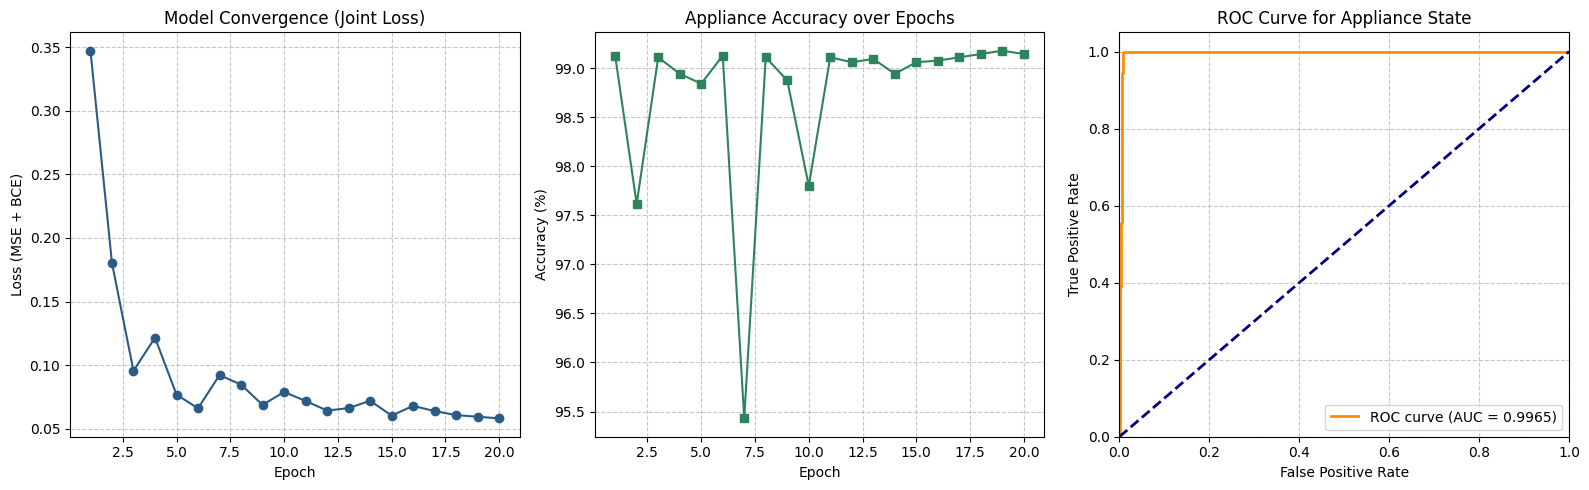


--- DATA SPARSITY CHECK ---
apartment_id
APT1    96.0
Name: shiftable_on, dtype: float64
---------------------------


PHASE 5: Running Explainable Recommendation for APT1
--------------------------------------------------
 Time  Pred_Total(W)  Shiftable_Prob(%)  Solar(W/m2)  Rec_Score
 9:00          104.5                0.0        450.0     -0.340
10:00          121.7                0.0        600.0     -0.472
11:00          117.5                0.0        800.0     -0.677
12:00          120.0                0.0        950.0     -0.824
--------------------------------------------------
🎯 EXPLAINABLE RECOMMENDATION FOR APT1:
Optimal context window to run heavy/shiftable loads is at 12:00.

🧠 SolarSync Reasoning:
This time slot was selected automatically because it features abundant solar surplus (950.0 W/m²) and standard off-peak ONEE pricing. Shifting load here maximizes your green energy utilization while mitigating grid strain.


In [ ]:
import pandas as pd
import numpy as np
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader, random_split
from sklearn.preprocessing import MinMaxScaler, LabelEncoder
from sklearn.metrics import r2_score, mean_absolute_error, accuracy_score, roc_auc_score
import glob
import os
import requests
import holidays
import warnings
import matplotlib.pyplot as plt
from sklearn.metrics import roc_curve

warnings.filterwarnings('ignore')

# ==========================================
# PHASE 1: DATA PIPELINE & RICH CONTEXT
# ==========================================
def process_mored_apartments_with_appliances(wp_dir, wpilgt_dir):
    print(f"PHASE 1: Fusing Aggregate Loads with Appliance Sub-Meters...\n" + "-" * 50)
    apt_files = glob.glob(os.path.join(wp_dir, 'APT*.csv'))
    clean_datasets = {}
    
    for file_path in apt_files:
        apt_name = os.path.basename(file_path).replace('.csv', '')
        print(f"Processing {apt_name}...")
        
        try:
            df_agg = pd.read_csv(file_path)
            df_agg['timestamp'] = pd.to_datetime(df_agg['timestamp'], errors='coerce', dayfirst=True)
            df_agg = df_agg.dropna(subset=['timestamp'])
            df_agg.set_index('timestamp', inplace=True)
            
            df_agg['real_power'] = pd.to_numeric(df_agg['real_power'], errors='coerce')
            df_15min_agg = df_agg[['real_power']].resample('15min').mean().interpolate(method='linear', limit=4).ffill().bfill()
            
            apt_appliance_dir = os.path.join(wpilgt_dir, apt_name)
            
            if os.path.exists(apt_appliance_dir):
                appliance_dfs = []
                appliance_files = glob.glob(os.path.join(apt_appliance_dir, '*.csv'))
                
                for app_file in appliance_files:
                    app_name = os.path.basename(app_file).replace('.csv', '')
                    if app_name in ['Events', 'Mains']: continue
                        
                    df_app = pd.read_csv(app_file)
                    df_app['timestamp'] = pd.to_datetime(df_app['timestamp'], errors='coerce')
                    df_app = df_app.dropna(subset=['timestamp'])
                    df_app.set_index('timestamp', inplace=True)
                    
                    df_app['real_power'] = pd.to_numeric(df_app['real_power'], errors='coerce')
                    df_app_15m = df_app[['real_power']].resample('15min').mean()
                    df_app_15m = df_app_15m.rename(columns={'real_power': f"{app_name}_power"})
                    appliance_dfs.append(df_app_15m)
                
                if appliance_dfs:
                    df_all_apps = pd.concat(appliance_dfs, axis=1)
                    df_combined = df_15min_agg.join(df_all_apps, how='left').fillna(0)
                else:
                    df_combined = df_15min_agg
            else:
                df_combined = df_15min_agg
            
            df_combined['apartment_id'] = apt_name
            clean_datasets[apt_name] = df_combined
            
        except Exception as e:
            print(f"  -> Error processing {apt_name}: {e}")
            
    return clean_datasets

def load_and_clean_pvgis(weather_csv_path):
    header_row_index = 0
    with open(weather_csv_path, 'r', encoding='utf-8') as f:
        for i, line in enumerate(f):
            if line.startswith('time'):
                header_row_index = i
                break
                
    df_weather = pd.read_csv(weather_csv_path, skiprows=header_row_index)
    df_weather.columns = df_weather.columns.str.strip()
    df_weather['time'] = df_weather['time'].astype(str).str.strip()
    df_weather['timestamp'] = pd.to_datetime(df_weather['time'], format='%Y%m%d:%H%M', errors='coerce')
    
    df_weather = df_weather.dropna(subset=['timestamp'])
    df_weather.set_index('timestamp', inplace=True)
    
    df_weather = df_weather[['T2m', 'G(i)', 'WS10m']].rename(columns={
        'T2m': 'temperature_c',
        'G(i)': 'solar_irradiance_w_m2',
        'WS10m': 'wind_speed_m_s'
    })
    
    for col in df_weather.columns:
        df_weather[col] = pd.to_numeric(df_weather[col], errors='coerce')
    
    df_weather.index = df_weather.index.round('15min')
    df_weather_15m = df_weather.resample('15min').interpolate(method='linear').bfill().ffill()
    return df_weather_15m

def fetch_real_historical_humidity(start_date, end_date, lat=31.6295, lon=-8.0366):
    try:
        url = f"https://archive-api.open-meteo.com/v1/archive?latitude={lat}&longitude={lon}&start_date={start_date}&end_date={end_date}&hourly=relative_humidity_2m"
        response = requests.get(url).json()
        times = pd.to_datetime(response['hourly']['time'])
        humidity = response['hourly']['relative_humidity_2m']
        humidity_df = pd.DataFrame({'timestamp': times, 'humidity_percent': humidity})
        humidity_df.set_index('timestamp', inplace=True)
        return humidity_df
    except Exception:
        return pd.DataFrame({'humidity_percent': 50.0}, index=pd.date_range(start=start_date, end=end_date, freq='H'))

def derive_semantic_weather(row):
    if row['solar_irradiance_w_m2'] > 600: sun_desc = "Clear/Sunny"
    elif row['solar_irradiance_w_m2'] > 200: sun_desc = "Partly Cloudy"
    else: sun_desc = "Overcast/Dark"
        
    if row['temperature_c'] > 30: temp_desc = "Hot"
    elif row['temperature_c'] < 15: temp_desc = "Cool"
    else: temp_desc = "Mild"
    return f"{temp_desc} & {sun_desc}"

def inject_rich_multimodal_context(df):
    df = df.copy()
    start_str = df.index.min().strftime('%Y-%m-%d')
    end_str = df.index.max().strftime('%Y-%m-%d')
    
    real_humidity_df = fetch_real_historical_humidity(start_str, end_str)
    df = df.join(real_humidity_df, how='left')
    df['humidity_percent'] = df['humidity_percent'].ffill().bfill()
    
    peak_hours = (df.index.hour >= 18) & (df.index.hour <= 23)
    df['real_price_MAD'] = 1.05 
    df.loc[peak_hours, 'real_price_MAD'] = 1.50 
    
    ma_holidays = holidays.Morocco(years=df.index.year.unique().tolist())
    df['day_type'] = "Standard_Workday"
    df.loc[df.index.dayofweek >= 5, 'day_type'] = "Weekend"
    for timestamp in df.index:
        if timestamp.date() in ma_holidays:
            df.loc[timestamp, 'day_type'] = f"Holiday_{ma_holidays.get(timestamp.date()).replace(' ', '_')}"
            
    df['social_context'] = "Standard"
    df.loc[(df.index >= '2020-03-20') & (df.index <= '2020-06-10'), 'social_context'] = "COVID_Strict_Lockdown"
    df.loc[(df.index >= '2020-04-24') & (df.index <= '2020-05-23'), 'social_context'] = "Ramadan_Lockdown"

    df['weather_semantic'] = df.apply(derive_semantic_weather, axis=1)

    df['grid_state'] = "STANDARD_LOAD"
    df.loc[peak_hours, 'grid_state'] = "PEAK_PENALTY"
    df.loc[df['solar_irradiance_w_m2'] > 500, 'grid_state'] = "HIGH_SOLAR_SURPLUS"

    df = df.dropna(subset=['temperature_c', 'solar_irradiance_w_m2', 'wind_speed_m_s', 'real_power'])
    return df

def merge_all_data(apartment_dict, weather_df):
    weather_df = weather_df[~weather_df.index.duplicated(keep='first')]
    all_fused_dfs = []
    
    for apt_name, apt_df in apartment_dict.items():
        apt_df = apt_df[~apt_df.index.duplicated(keep='first')]
        fused_df = apt_df.join(weather_df, how='left') 
        all_fused_dfs.append(fused_df)
        
    master_df = pd.concat(all_fused_dfs)
    return inject_rich_multimodal_context(master_df)

def engineer_phd_dataset(df):
    """Semantic Appliance Aggregation and Binary Classification Target."""
    print("\nEnriching dataset with Appliance Ontology and Cyclical Features...")
    df = df.copy()

    # 1. Semantic Appliance Aggregation
    shiftable_cols = [c for c in df.columns if 'Washing' in c or 'Dish_washer' in c]
    thermal_cols = [c for c in df.columns if 'Refrigerator' in c or 'Freezer' in c or 'Water_heater' in c]
    base_cols = [c for c in df.columns if '_power' in c and c not in shiftable_cols and c not in thermal_cols and c != 'real_power']

    raw_shiftable_power = df[shiftable_cols].sum(axis=1) if shiftable_cols else 0.0
    
    # ---> CLASSIFICATION UPGRADE: Convert continuous watts to Binary ON/OFF (15W noise threshold)
    df['shiftable_on'] = (raw_shiftable_power > 15.0).astype(float)
    
    df = df.drop(columns=shiftable_cols + thermal_cols + base_cols)

    # 2. Cyclical Time Encoding
    df['hour_sin'] = np.sin(2 * np.pi * df.index.hour / 24)
    df['hour_cos'] = np.cos(2 * np.pi * df.index.hour / 24)
    df['month_sin'] = np.sin(2 * np.pi * df.index.month / 12)
    df['month_cos'] = np.cos(2 * np.pi * df.index.month / 12)

    # 3. Thermal Inertia (Rolling Context)
    df['temp_3hr_rolling_avg'] = df.groupby('apartment_id')['temperature_c'].transform(lambda x: x.rolling(window=12, min_periods=1).mean()).bfill()
    df['solar_3hr_rolling_avg'] = df.groupby('apartment_id')['solar_irradiance_w_m2'].transform(lambda x: x.rolling(window=12, min_periods=1).mean()).bfill()

    return df

# ==========================================
# PHASE 2: REGRESSION + CLASSIFICATION ARX-LSTM
# ==========================================
class SmartGridLSTMDataset(Dataset):
    def __init__(self, dataframe, seq_length=8):
        self.df = dataframe.copy()
        self.seq_length = seq_length
        
        self.cont_cols = [
            'temperature_c', 'solar_irradiance_w_m2', 'wind_speed_m_s', 'humidity_percent', 
            'real_price_MAD', 'hour_sin', 'hour_cos', 'month_sin', 'month_cos', 
            'temp_3hr_rolling_avg', 'solar_3hr_rolling_avg', 'real_power'
        ]
        self.feature_scaler = MinMaxScaler()
        self.continuous_features = self.feature_scaler.fit_transform(self.df[self.cont_cols].values)
        
        # ---> TARGET SPLIT: Scale total power, leave binary target as-is
        self.target_scaler_total = MinMaxScaler()
        self.target_total = self.target_scaler_total.fit_transform(self.df[['real_power']].values)
        self.target_shiftable = self.df[['shiftable_on']].values
        
        self.df['hour'] = self.df.index.hour
        self.df['day'] = self.df.index.dayofweek
        self.cat_cols = ['apartment_id', 'hour', 'day', 'day_type', 'social_context', 'weather_semantic', 'grid_state']
        
        self.encoders = {}
        self.encoded_cats = np.zeros((len(self.df), len(self.cat_cols)), dtype=np.int64)
        
        for i, col in enumerate(self.cat_cols):
            le = LabelEncoder()
            self.encoded_cats[:, i] = le.fit_transform(self.df[col])
            self.encoders[col] = le
            
        self.vocab_sizes = {col: len(le.classes_) for col, le in self.encoders.items()}
        self.vocab_sizes['hour'] = 24
        self.vocab_sizes['day'] = 7

    def __len__(self):
        return len(self.df) - self.seq_length

    def __getitem__(self, idx):
        cat_seq = torch.tensor(self.encoded_cats[idx : idx + self.seq_length], dtype=torch.long)
        cont_seq = torch.tensor(self.continuous_features[idx : idx + self.seq_length], dtype=torch.float32)
        
        # Combine the two structurally different targets into one tensor
        target = torch.tensor([
            self.target_total[idx + self.seq_length][0],
            self.target_shiftable[idx + self.seq_length][0]
        ], dtype=torch.float32)
        
        return cat_seq, cont_seq, target

class SolarSyncLSTMModel(nn.Module):
    def __init__(self, vocab_sizes, embedding_dim=8, lstm_hidden=64):
        super(SolarSyncLSTMModel, self).__init__()
        
        self.embeddings = nn.ModuleList([
            nn.Embedding(vocab_sizes[col], embedding_dim) for col in vocab_sizes.keys()
        ])
        
        num_continuous = 12 
        num_categorical = len(self.embeddings)
        lstm_input_dim = (num_categorical * embedding_dim) + num_continuous 
        
        self.lstm = nn.LSTM(input_size=lstm_input_dim, hidden_size=lstm_hidden, batch_first=True)
        
        # Regression Head (Predicts Watts)
        self.fc_total = nn.Sequential(
            nn.Dropout(0.2),
            nn.Linear(lstm_hidden, lstm_hidden // 2),
            nn.ReLU(),
            nn.Linear(lstm_hidden // 2, 1)
        )
        # Classification Head (Predicts Logits for Probability)
        self.fc_shiftable = nn.Sequential(
            nn.Dropout(0.2),
            nn.Linear(lstm_hidden, lstm_hidden // 2),
            nn.ReLU(),
            nn.Linear(lstm_hidden // 2, 1)
        )

    def forward(self, cat_seq, cont_seq):
        embedded = [self.embeddings[i](cat_seq[:, :, i]) for i in range(len(self.embeddings))]
        fused_cats = torch.cat(embedded, dim=2)
        fused_seq = torch.cat([fused_cats, cont_seq], dim=2) 
        
        lstm_out, (hn, cn) = self.lstm(fused_seq)
        final_state = hn[-1, :, :] 
        
        pred_total = self.fc_total(final_state)
        pred_shiftable = self.fc_shiftable(final_state)
        return torch.cat([pred_total, pred_shiftable], dim=1)

# ==========================================
# PHASE 3: TRAINING & ACADEMIC EVALUATION
# ==========================================
def train_and_evaluate(dataset, epochs=20, batch_size=128, lr=0.003):
    print("\nPHASE 3: Training Hybrid ARX-LSTM with Class Weighting...\n" + "-" * 50)
    
    train_size = int(0.8 * len(dataset))
    test_size = len(dataset) - train_size
    train_dataset, test_dataset = random_split(dataset, [train_size, test_size])
    
    train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)
    test_loader = DataLoader(test_dataset, batch_size=batch_size, shuffle=False)
    
    model = SolarSyncLSTMModel(dataset.vocab_sizes)
    
    num_positives = np.sum(dataset.target_shiftable)
    num_negatives = len(dataset.target_shiftable) - num_positives
    
    weight_val = num_negatives / (num_positives + 1e-5)
    pos_weight = torch.tensor([weight_val], dtype=torch.float32)
    
    print(f"Data Imbalance Detected: {int(num_negatives)} OFF states vs {int(num_positives)} ON states.")
    print(f"Applying BCE Positive Weight: {weight_val:.2f}")
    
    criterion_reg = nn.MSELoss() 
    criterion_clf = nn.BCEWithLogitsLoss(pos_weight=pos_weight) 
    
    optimizer = optim.Adam(model.parameters(), lr=lr)
    
    # --- History Trackers for Plotting ---
    history_loss = []
    history_acc = []
    
    for epoch in range(epochs):
        model.train()
        epoch_loss = 0.0
        
        for cat_seq, cont_seq, target in train_loader:
            optimizer.zero_grad()
            predictions = model(cat_seq, cont_seq)
            
            loss_reg = criterion_reg(predictions[:, 0], target[:, 0])
            loss_clf = criterion_clf(predictions[:, 1], target[:, 1])
            
            loss = loss_reg + loss_clf 
            loss.backward()
            optimizer.step()
            epoch_loss += loss.item()
            
        avg_loss = epoch_loss / len(train_loader)
        history_loss.append(avg_loss)
        
        # --- Epoch Validation (to track accuracy over time) ---
        model.eval()
        val_preds, val_targets = [], []
        with torch.no_grad():
            for cat_seq, cont_seq, target in test_loader:
                preds = model(cat_seq, cont_seq)
                val_preds.extend(preds.numpy())
                val_targets.extend(target.numpy())
        
        val_preds = np.array(val_preds)
        val_targets = np.array(val_targets)
        
        # Track classification accuracy per epoch
        pred_probs = torch.sigmoid(torch.tensor(val_preds[:, 1])).numpy()
        pred_labels = (pred_probs > 0.5).astype(float)
        epoch_acc = accuracy_score(val_targets[:, 1], pred_labels)
        history_acc.append(epoch_acc * 100)
        
        if (epoch + 1) % 5 == 0 or epoch == 0:
            print(f"Epoch [{epoch + 1}/{epochs}] | Joint Train Loss: {avg_loss:.5f} | Val Acc: {epoch_acc*100:.2f}%")
            
    # --- Final Formal Evaluation ---
    print("\nPHASE 4: Evaluating Model on Unseen Test Sequences...")
    
    real_preds_total = dataset.target_scaler_total.inverse_transform(val_preds[:, 0].reshape(-1, 1))
    real_targets_total = dataset.target_scaler_total.inverse_transform(val_targets[:, 0].reshape(-1, 1))
    
    pred_probs_shiftable = torch.sigmoid(torch.tensor(val_preds[:, 1])).numpy()
    pred_labels_shiftable = (pred_probs_shiftable > 0.5).astype(float)
    
    r2_total = r2_score(real_targets_total, real_preds_total)
    mae_total = mean_absolute_error(real_targets_total, real_preds_total)
    acc_shift = accuracy_score(val_targets[:, 1], pred_labels_shiftable)
    
    try:
        auc_shift = roc_auc_score(val_targets[:, 1], pred_probs_shiftable)
    except ValueError:
        auc_shift = float('nan') 
    
    print("-" * 50)
    print("FINAL TEST METRICS (HYBRID MODEL):")
    print(f"Total Load (Regression) R-Squared: {r2_total:.4f} ({r2_total*100:.2f}%)")
    print(f"Total Load (Regression) MAE:       ±{mae_total:.2f} Watts")
    print(f"Appliance (Classification) Acc:    {acc_shift*100:.2f}%")
    if not np.isnan(auc_shift):
        print(f"Appliance (Classification) AUC:    {auc_shift:.4f}")
    print("-" * 50)
    
    # ==========================================
    # ACADEMIC PLOTTING BLOCK (Dynamic Display)
    # ==========================================
    from sklearn.metrics import roc_curve


    print("\nGenerating visual plots for presentation (Close the popup window to continue)...")
    plt.figure(figsize=(16, 5))
    
    # Plot 1: Joint Train Loss
    plt.subplot(1, 3, 1)
    plt.plot(range(1, epochs + 1), history_loss, marker='o', color='#2b5b84')
    plt.title('Model Convergence (Joint Loss)')
    plt.xlabel('Epoch')
    plt.ylabel('Loss (MSE + BCE)')
    plt.grid(True, linestyle='--', alpha=0.7)
    
    # Plot 2: Validation Accuracy over Epochs
    plt.subplot(1, 3, 2)
    plt.plot(range(1, epochs + 1), history_acc, marker='s', color='#2b845b')
    plt.title('Appliance Accuracy over Epochs')
    plt.xlabel('Epoch')
    plt.ylabel('Accuracy (%)')
    plt.grid(True, linestyle='--', alpha=0.7)
    
    # Plot 3: Final ROC Curve
    plt.subplot(1, 3, 3)
    if not np.isnan(auc_shift):
        fpr, tpr, _ = roc_curve(val_targets[:, 1], pred_probs_shiftable)
        plt.plot(fpr, tpr, color='darkorange', lw=2, label=f'ROC curve (AUC = {auc_shift:.4f})')
        plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')
        plt.xlim([0.0, 1.0])
        plt.ylim([0.0, 1.05])
        plt.xlabel('False Positive Rate')
        plt.ylabel('True Positive Rate')
        plt.title('ROC Curve for Appliance State')
        plt.legend(loc="lower right")
        plt.grid(True, linestyle='--', alpha=0.7)
    else:
        plt.title('ROC Curve (Insufficient Positives)')
        
    plt.tight_layout()
    plt.show()  # This halts execution and pops up the UI window
    
    return model

# ==========================================
# PHASE 5: EXPLAINABLE MULTI-OBJECTIVE RECOMMENDATION
# ==========================================
def simulate_recommendations(model, dataset, historical_context_df, forecasted_options, target_apartment='APT1'):
    print(f"\nPHASE 5: Running Explainable Recommendation for {target_apartment}\n" + "-" * 50)
    model.eval()
    results = []
    
    seq_len = dataset.seq_length
    apt_int_indices = np.where(dataset.df['apartment_id'] == target_apartment)[0]
    
    if len(apt_int_indices) < seq_len:
        print(f"Not enough data for {target_apartment} to simulate.")
        return
        
    last_apt_idx = apt_int_indices[-1]
    hist_cat = dataset.encoded_cats[last_apt_idx - seq_len + 1 : last_apt_idx + 1]
    hist_cont = dataset.continuous_features[last_apt_idx - seq_len + 1 : last_apt_idx + 1]
    
    last_known_power = historical_context_df['real_power'].iloc[last_apt_idx]
    last_known_temp_rolling = historical_context_df['temp_3hr_rolling_avg'].iloc[last_apt_idx]
    last_known_solar_rolling = historical_context_df['solar_3hr_rolling_avg'].iloc[last_apt_idx]
    
    for option in forecasted_options:
        hour_sin = np.sin(2 * np.pi * option['hour'] / 24)
        hour_cos = np.cos(2 * np.pi * option['hour'] / 24)
        month_sin = np.sin(2 * np.pi * option['month'] / 12)
        month_cos = np.cos(2 * np.pi * option['month'] / 12)
        
        sim_cat = [
            dataset.encoders['apartment_id'].transform([target_apartment])[0], 
            option['hour'], option['day'],
            dataset.encoders['day_type'].transform([option['day_type']])[0],
            dataset.encoders['social_context'].transform([option['social_context']])[0],
            dataset.encoders['weather_semantic'].transform([option['weather_semantic']])[0],
            dataset.encoders['grid_state'].transform([option['grid_state']])[0]
        ]
        
        sim_cont = dataset.feature_scaler.transform([[
            option['temp'], option['solar'], option['wind'], option['hum'], option['price'],
            hour_sin, hour_cos, month_sin, month_cos, 
            last_known_temp_rolling, last_known_solar_rolling, last_known_power
        ]])[0]
        
        full_cat_seq = np.vstack([hist_cat, sim_cat])
        full_cont_seq = np.vstack([hist_cont, sim_cont])
        
        cat_tensor = torch.tensor(full_cat_seq, dtype=torch.long).unsqueeze(0)
        cont_tensor = torch.tensor(full_cont_seq, dtype=torch.float32).unsqueeze(0)
        
        with torch.no_grad():
            pred_scaled = model(cat_tensor, cont_tensor)
            
        pred_total_watts = dataset.target_scaler_total.inverse_transform([[pred_scaled[0][0].item()]])[0][0]
        pred_shiftable_prob = torch.sigmoid(torch.tensor(pred_scaled[0][1].item())).item() * 100
        
        estimated_cost = (pred_total_watts / 1000) * option['price'] 
        score = estimated_cost - (0.001 * option['solar'])
        
        results.append({
            'Time': f"{option['hour']}:00",
            'Pred_Total(W)': round(pred_total_watts, 1),
            'Shiftable_Prob(%)': round(pred_shiftable_prob, 2),
            'Solar(W/m2)': option['solar'],
            'Price(MAD)': option['price'],
            'Rec_Score': round(score, 3)
        })

    results_df = pd.DataFrame(results)
    best_hour_data = results_df.loc[results_df['Rec_Score'].idxmin()]
    
    # ---> EXPLAINABLE AI (XAI) MODULE <---
    avg_load = results_df['Pred_Total(W)'].mean()
    reasons = []
    
    if best_row_solar := best_hour_data['Solar(W/m2)'] > 500:
        reasons.append(f"abundant solar surplus ({best_hour_data['Solar(W/m2)']} W/m²)")
    elif best_hour_data['Solar(W/m2)'] > 200:
        reasons.append(f"moderate solar availability ({best_hour_data['Solar(W/m2)']} W/m²)")
        
    if best_hour_data['Price(MAD)'] < 1.50:
        reasons.append("standard off-peak ONEE pricing")
        
    if best_hour_data['Pred_Total(W)'] < avg_load:
        reasons.append(f"a lower predicted baseline grid load ({best_hour_data['Pred_Total(W)']} W) compared to surrounding hours")
        
    explanation = " and ".join(reasons) if reasons else "an optimal balance of grid factors"

    print(results_df.drop(columns=['Price(MAD)']).to_string(index=False)) # Hide price from table to keep it clean, but use it in logic
    print("-" * 50)
    print(f"🎯 EXPLAINABLE RECOMMENDATION FOR {target_apartment}:")
    print(f"Optimal context window to run heavy/shiftable loads is at {best_hour_data['Time']}.")
    print(f"\n🧠 SolarSync Reasoning:\nThis time slot was selected automatically because it features {explanation}. Shifting load here maximizes your green energy utilization while mitigating grid strain.")


# ==========================================
# MASTER EXECUTION
# ==========================================
if __name__ == "__main__":
    WP_DIR = './data/mored_data/WP' 
    WPILGT_DIR = './data/mored_data/WPILGT'
    WEATHER_FILE = './data/pvgis_data.csv'
    CACHE_FILE = './data/master_multimodal_lstm_dataset.csv'
    
    rebuild_cache = True
    
    if os.path.exists(CACHE_FILE):
        print(f"\nCACHE FOUND: Loading dataset directly from '{CACHE_FILE}'...")
        master_df = pd.read_csv(CACHE_FILE)
        master_df['timestamp'] = pd.to_datetime(master_df['timestamp'])
        master_df.set_index('timestamp', inplace=True)
        
        # Check if it's the old cache missing our new engineered features
        if 'hour_sin' in master_df.columns and 'shiftable_on' in master_df.columns:
            rebuild_cache = False
        else:
            print("-> Outdated cache detected (missing new semantic features). Forcing rebuild...")
            
    if rebuild_cache:
        print("\nNO VALID CACHE FOUND: Running Full Data Pipeline...")
        apt_data = process_mored_apartments_with_appliances(WP_DIR, WPILGT_DIR)
        weather_data = load_and_clean_pvgis(WEATHER_FILE)
        raw_df = merge_all_data(apt_data, weather_data)
        master_df = engineer_phd_dataset(raw_df)
        
        print(f"\nExporting the final rich dataset to '{CACHE_FILE}'...")
        master_df.to_csv(CACHE_FILE)
        print("Export complete!")
    
    print("\nFixing missing (null) data by filling with 0...")
    master_df = master_df.fillna(0)
    
    grid_dataset = SmartGridLSTMDataset(master_df, seq_length=8)
    trained_model = train_and_evaluate(grid_dataset, epochs=20)

    # Add this to your "Master Execution" block
    torch.save(trained_model.state_dict(), 'solarsync_model.pth')

    import joblib
    joblib.dump(grid_dataset.feature_scaler, 'feature_scaler.pkl')
    joblib.dump(grid_dataset.target_scaler_total, 'target_scaler.pkl')
    joblib.dump(grid_dataset.encoders, 'label_encoders.pkl')
    
    # Simulating a Sunday morning where laundry is highly likely
    mock_forecasted_options = [
        {'month': 4, 'hour': 9, 'day': 6, 'day_type': 'Weekend', 'social_context': 'Standard', 'weather_semantic': 'Mild & Clear/Sunny', 'grid_state': 'STANDARD_LOAD', 'temp': 20.0, 'solar': 450.0, 'wind': 2.0, 'hum': 60.0, 'price': 1.05},
        {'month': 4, 'hour': 10, 'day': 6, 'day_type': 'Weekend', 'social_context': 'Standard', 'weather_semantic': 'Mild & Clear/Sunny', 'grid_state': 'STANDARD_LOAD', 'temp': 22.0, 'solar': 600.0, 'wind': 2.5, 'hum': 55.0, 'price': 1.05},
        {'month': 4, 'hour': 11, 'day': 6, 'day_type': 'Weekend', 'social_context': 'Standard', 'weather_semantic': 'Hot & Clear/Sunny', 'grid_state': 'STANDARD_LOAD', 'temp': 25.0, 'solar': 800.0, 'wind': 3.0, 'hum': 50.0, 'price': 1.05},
        {'month': 4, 'hour': 12, 'day': 6, 'day_type': 'Weekend', 'social_context': 'Standard', 'weather_semantic': 'Hot & Clear/Sunny', 'grid_state': 'HIGH_SOLAR_SURPLUS', 'temp': 27.0, 'solar': 950.0, 'wind': 3.5, 'hum': 45.0, 'price': 1.05}
    ]

    # --- QUICK DIAGNOSTIC: Find which apartments actually do laundry ---
    print("\n--- DATA SPARSITY CHECK ---")
    active_apts = master_df.groupby('apartment_id')['shiftable_on'].sum()
    print(active_apts[active_apts > 0])
    print("---------------------------\n")

    simulate_recommendations(trained_model, grid_dataset, master_df, mock_forecasted_options, target_apartment='APT1')
